## Cavalier Kaggles - Project 3 Code

The following notebook contains all the code necessary to reproduce our results. Please run the cells in the order and manner listed. Explanatory comments are provided throughout.

#### **Step 1:** import dependencies

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

#### **Step 2:** set working directory and define global model variables

In [ ]:
#set workign directory
working_dir = 'C:/Users/dinos/OneDrive/Desktop/College/8th Semester/DS 4002 - Data Science Project/Project 3'
os.chdir(working_dir)

#set basic configurations
CSV_PATH = 'Data_Entry_2017_v2020.csv' # metadata file
IMAGE_DIR = 'images' # data folder in directory
RANDOM_STATE = 4002
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
IMAGE_SIZE = 224
BEST_MODEL_PATH = 'best_binary_finding_model.pt'

#### **Step 3:** read in patient metadata

In [3]:
patient_df = pd.read_csv(CSV_PATH)
patient_df = patient_df.rename(columns={'OriginalImagePixelSpacing[x':'PixelSpacingX','y]':'PixelSpacingY','OriginalImage[Width':'OriginalWidth','Height]':'OriginalHeight'})
patient_df.head(5)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalWidth,OriginalHeight,PixelSpacingX,PixelSpacingY
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168


In [4]:
print('Total number of images: ',len(patient_df))
print('Total number of unique patients: ', patient_df['Patient ID'].nunique())

Total number of images:  112120
Total number of unique patients:  30805


#### **Step 4:** split multi-label entries into arrays; find and display counts of each disease

In [5]:
all_labels_lists = patient_df['Finding Labels'].str.split('|') #returns a list of lists, where each list contains strings
all_diseases_flat = []
for row in all_labels_lists: #loop through each list (i.e. row) represented
    for disease in row: #within each list, loop through its elements and append to growing list
        all_diseases_flat.append(disease)
disease_counts = Counter(all_diseases_flat)
disease_counts_df = pd.DataFrame.from_dict(disease_counts, orient='index',columns=['Count']).sort_values('Count',ascending=False)
disease_counts_df

,Count
No Finding,60361
Infiltration,19894
Effusion,13317
Atelectasis,11559
Nodule,6331
Mass,5782
Pneumothorax,5302
Consolidation,4667
Pleural_Thickening,3385
Cardiomegaly,2776


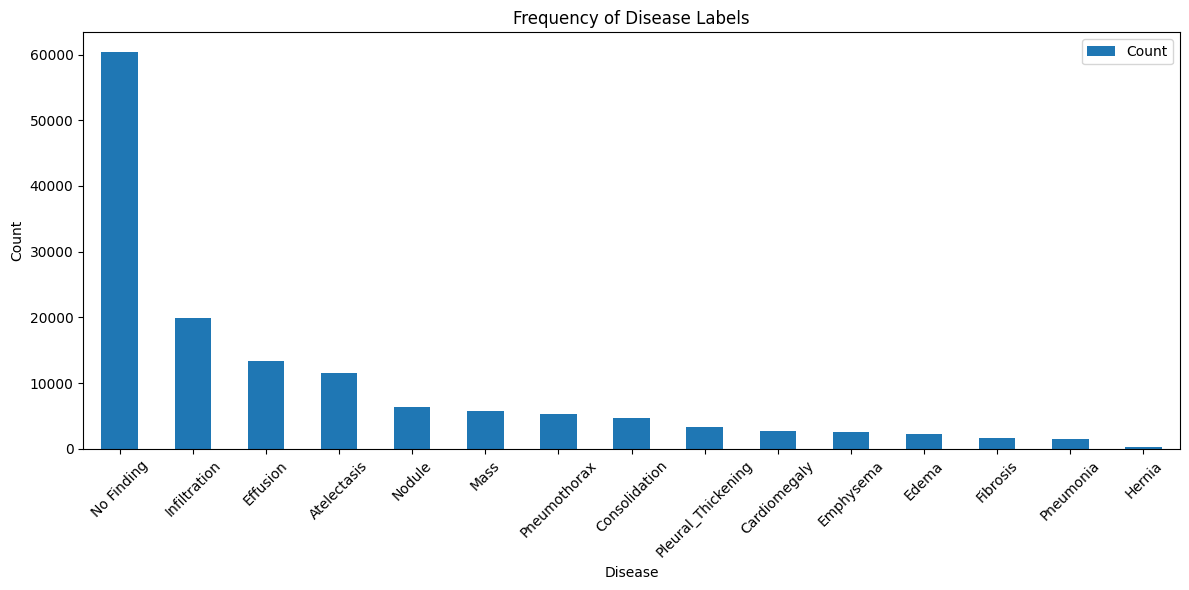

In [6]:
disease_counts_df.plot(kind='bar',figsize=(12,6))
plt.title('Frequency of Disease Labels')
plt.ylabel('Count')
plt.xlabel('Disease')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Step 5:** recode disease labels into binary outcome; find and display counts of each outcome

In [49]:
def encode_labels(label_string):
    """
    Convert NIH label string into a binary target.

    Returns
    -------
    float
        0 if the image is labeled 'No Finding'
        1 if the image has any abnormal finding (e.g. a disease state)
    """
    if label_string.strip() == 'No Finding':
        return 0.0
    else:
        return 1.0


In [50]:
patient_df['binary_label'] = patient_df['Finding Labels'].apply(encode_labels)
patient_df.head(5)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalWidth,OriginalHeight,PixelSpacingX,PixelSpacingY,binary_label
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143,1.0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,1.0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,1.0
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171,0.0
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168,1.0


binary_label
0.0    60361
1.0    51759
Name: count, dtype: int64


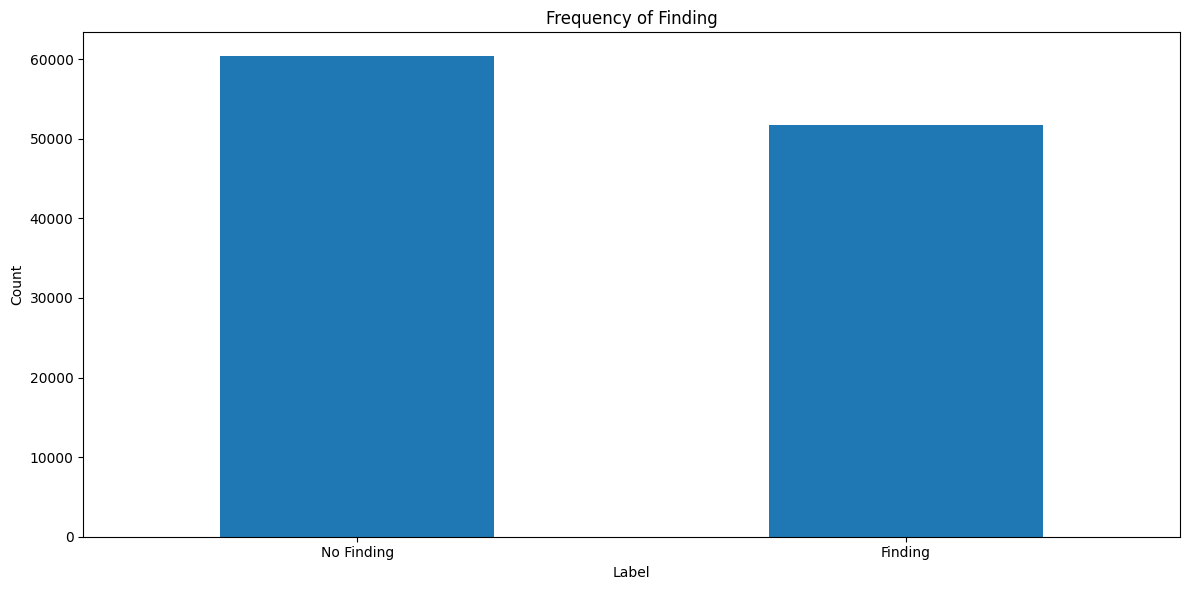

In [51]:
binary_counts = patient_df['binary_label'].value_counts().sort_index()
print(binary_counts)

binary_counts.plot(kind='bar',figsize=(12,6))
plt.title('Frequency of Finding')
plt.ylabel('Count')
plt.xlabel('Label')
plt.xticks(ticks=[0,1],labels=['No Finding','Finding'],rotation = 0)
plt.tight_layout()
plt.show()

#### **Step 6:** define test, validation, and test sets on a by-patient basis using the provided metadata file

In [10]:
patient_ids = patient_df['Patient ID'].unique()

train_patients, temp_patients = train_test_split(patient_ids, test_size=0.3,random_state=RANDOM_STATE)

val_patients, test_patients = train_test_split(temp_patients,test_size = 0.5,random_state=RANDOM_STATE)


In [11]:
train_df = patient_df[patient_df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df = patient_df[patient_df['Patient ID'].isin(val_patients)].reset_index(drop=True)
test_df = patient_df[patient_df['Patient ID'].isin(test_patients)].reset_index(drop=True)

#### **Step 7:** download images
**Only run as necessary.**

In [12]:
"""#download files
import urllib.request
links = [
    'https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz',
    'https://nihcc.box.com/shared/static/i28rlmbvmfjbl8p2n3ril0pptcmcu9d1.gz',
    'https://nihcc.box.com/shared/static/f1t00wrtdk94satdfb9olcolqx20z2jp.gz',
	'https://nihcc.box.com/shared/static/0aowwzs5lhjrceb3qp67ahp0rd1l1etg.gz',
    'https://nihcc.box.com/shared/static/v5e3goj22zr6h8tzualxfsqlqaygfbsn.gz',
	'https://nihcc.box.com/shared/static/asi7ikud9jwnkrnkj99jnpfkjdes7l6l.gz',
	'https://nihcc.box.com/shared/static/jn1b4mw4n6lnh74ovmcjb8y48h8xj07n.gz',
    'https://nihcc.box.com/shared/static/tvpxmn7qyrgl0w8wfh9kqfjskv6nmm1j.gz',
	'https://nihcc.box.com/shared/static/upyy3ml7qdumlgk2rfcvlb9k6gvqq2pj.gz',
	'https://nihcc.box.com/shared/static/l6nilvfa9cg3s28tqv1qc1olm3gnz54p.gz',
	'https://nihcc.box.com/shared/static/hhq8fkdgvcari67vfhs7ppg2w6ni4jze.gz',
	'https://nihcc.box.com/shared/static/ioqwiy20ihqwyr8pf4c24eazhh281pbu.gz'
]

for idx, link in enumerate(links):
    fn = 'images_%02d.tar.gz' % (idx+1)
    print('downloading'+fn+'...')
    urllib.request.urlretrieve(link, fn)  # download the zip file

print("Download complete. Please check the checksums")"""

'#download files\nimport urllib.request\nlinks = [\n    \'https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz\',\n    \'https://nihcc.box.com/shared/static/i28rlmbvmfjbl8p2n3ril0pptcmcu9d1.gz\',\n    \'https://nihcc.box.com/shared/static/f1t00wrtdk94satdfb9olcolqx20z2jp.gz\',\n\t\'https://nihcc.box.com/shared/static/0aowwzs5lhjrceb3qp67ahp0rd1l1etg.gz\',\n    \'https://nihcc.box.com/shared/static/v5e3goj22zr6h8tzualxfsqlqaygfbsn.gz\',\n\t\'https://nihcc.box.com/shared/static/asi7ikud9jwnkrnkj99jnpfkjdes7l6l.gz\',\n\t\'https://nihcc.box.com/shared/static/jn1b4mw4n6lnh74ovmcjb8y48h8xj07n.gz\',\n    \'https://nihcc.box.com/shared/static/tvpxmn7qyrgl0w8wfh9kqfjskv6nmm1j.gz\',\n\t\'https://nihcc.box.com/shared/static/upyy3ml7qdumlgk2rfcvlb9k6gvqq2pj.gz\',\n\t\'https://nihcc.box.com/shared/static/l6nilvfa9cg3s28tqv1qc1olm3gnz54p.gz\',\n\t\'https://nihcc.box.com/shared/static/hhq8fkdgvcari67vfhs7ppg2w6ni4jze.gz\',\n\t\'https://nihcc.box.com/shared/static/ioqwiy20ihqwyr8pf4

#### **Step 8:** ensure that sets are split correctly without overlap and that images load correctly

In [13]:
#verify no overlap between sets
train_patient_set = set(train_df['Patient ID'])
val_patient_set = set(val_df['Patient ID'])
test_patient_set = set(test_df['Patient ID'])

print(f"Train-Val overlap: {len(train_patient_set.intersection(val_patient_set))}")
print(f"Train-Test overlap: {len(train_patient_set.intersection(test_patient_set))}")
print(f"Val-Test overlap: {len(val_patient_set.intersection(test_patient_set))}")

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


Sample image mode:  L
Sample image size:  (1024, 1024)


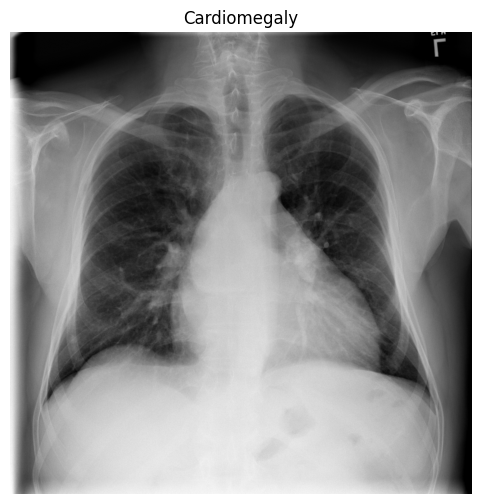

In [14]:
#test image loading
sample_file = train_df.loc[0,"Image Index"]
sample_path = os.path.join(IMAGE_DIR, sample_file)

sample_image = Image.open(sample_path)

print('Sample image mode: ', sample_image.mode)
print('Sample image size: ', sample_image.size)

plt.figure(figsize=(6,6))
plt.imshow(sample_image, cmap='gray')
plt.title(train_df.loc[0,"Finding Labels"])
plt.axis('off')
plt.show()

#### **Step 9:** define the appropriate image transofrmations for compatibility with the DenseNet model

In [ ]:
#transform to standard image size for existing model
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3,1,1)), #only one grayscale channel, so repeat 3 times
    #use ImageNet parameters since DenseNet trained on that
    transforms.Normalize(
        mean = [0.485,0.456,0.406],
        std = [0.229,0.224,0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3,1,1)), #only one grayscale channel, so repeat 3 times
     transforms.Normalize(
        #use ImageNet parameters since DenseNet trained on that
        mean = [0.485,0.456,0.406],
        std = [0.229,0.224,0.225]
    )
])

#### **Step 10:** define a subclass to facilitate loading of images into PyTorch- and DenseNet-friendly formats

In [31]:
class NIHChestXrayBinaryDataset(Dataset):
    def __init__(self,df,image_dir,transform=None):
        """
        df: pd.DataFrame
            Must contain 'Image Index' and 'binary_label'
        image_dir: str
            Folder (name) containing image files
        transform: torchvision transform pipeline or None
            Transform to apply to images
        """
        self.df = df
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_name = row['Image Index']
        image_path = os.path.join(self.image_dir, image_name)

        image = Image.open(image_path).convert('L')

        label = torch.tensor(row['binary_label'],dtype=torch.float32)

        if self.transform is not None:
            image = self.transform(image)

        return image, label



#### **Step 11:** transform the images into new datasets using the new class and put into batches

In [32]:
train_dataset = NIHChestXrayBinaryDataset(
    df = train_df,
    image_dir = IMAGE_DIR,
    transform = train_transform
)

val_dataset = NIHChestXrayBinaryDataset(
    df = val_df,
    image_dir = IMAGE_DIR,
    transform = val_test_transform
)

test_dataset = NIHChestXrayBinaryDataset(
    df = test_df,
    image_dir = IMAGE_DIR,
    transform = val_test_transform
)

train_loader = DataLoader (
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [33]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


#### **Step 12:** load the appropriate device
Preferably uses a GPU if an GPU-friendly version of PyTorch is installed through NVIDIA.

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device: ", device)
print("GPU available: ", torch.cuda.is_available())

Using device:  cuda
GPU available:  True


#### **Step 13:** load the pretrained model and add custom classification layer

In [35]:
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features,1)
model = model.to(device)


#### **Step 14:** calculate class weights

In [36]:
positive_count = (train_df['binary_label'] == 1).sum()
negative_count = (train_df['binary_label'] == 0).sum()

positive_weight = negative_count / (positive_count + 1e-6)
positive_weight_tensor = torch.tensor([positive_weight], dtype=torch.float32).to(device)

print("Positive class weight: ", positive_weight)

Positive class weight:  1.1714828792272531


#### **Step 15:** define training and validation functions

In [ ]:
# Initialize GradScaler for mixed precision training on CUDA.
# This helps prevent underflow when using float16 by dynamically scaling the loss.
scaler = torch.amp.GradScaler("cuda")

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    # Set model to training mode (enables dropout, batchnorm updates, etc.)
    model.train()
    running_loss = 0.0

    # Loop over all batches in the training dataloader
    for images, labels in dataloader:        
        # Move data to GPU (or specified device)
        # non_blocking=True can improve performance when using pinned memory
        images = images.to(device, non_blocking=True)
        labels = labels.to(device).float().view(-1, 1)  # ensure labels match output shape

        # Reset gradients efficiently (set_to_none=True is slightly faster and uses less memory)
        optimizer.zero_grad(set_to_none=True)

        # Enable automatic mixed precision (AMP)
        # Operations inside this block run in float16 where safe, improving speed and memory usage
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(images)          # forward pass
            loss = criterion(outputs, labels)  # compute loss

        # Scale the loss before backpropagation to avoid numerical underflow
        scaler.scale(loss).backward()

        # Step the optimizer using the scaled gradients
        scaler.step(optimizer)

        # Update the scale for next iteration (dynamic adjustment)
        scaler.update()

        # Accumulate loss for reporting
        running_loss += loss.item()

    # Return average loss over all batches
    return running_loss / len(dataloader)


def validate_one_epoch(model, dataloader, criterion, device):
    # Set model to evaluation mode (disables dropout, uses running stats for batchnorm)
    model.eval()
    running_loss = 0.0

    # Store all labels and predicted probabilities for AUC computation
    all_labels = []
    all_probabilities = []

    # Disable gradient computation for validation (saves memory and computation)
    with torch.no_grad():
        for images, labels in dataloader:
            # Move data to device
            images = images.to(device, non_blocking=True)
            labels = labels.to(device).float().view(-1, 1)

            # Use mixed precision during validation as well for speed
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(images)           # forward pass
                loss = criterion(outputs, labels)  # compute loss

            # Convert raw logits to probabilities using sigmoid (for binary classification)
            probabilities = torch.sigmoid(outputs)

            # Accumulate loss
            running_loss += loss.item()

            # Move tensors to CPU and store for later metric computation
            all_labels.append(labels.cpu())
            all_probabilities.append(probabilities.cpu())

    # Compute average validation loss
    val_loss = running_loss / len(dataloader)

    # Concatenate all batches into single arrays
    all_labels = torch.cat(all_labels).numpy()
    all_probabilities = torch.cat(all_probabilities).numpy()

    # Compute AUROC (Area Under ROC Curve) for evaluation
    val_auc = roc_auc_score(all_labels, all_probabilities)

    return val_loss, val_auc

#### **Step 16:** train only the classifier

In [ ]:
# Freeze all backbone (feature extractor) layers so their weights are not updated
# during Stage 1 training. This allows us to train only the classifier head first.
for param in model.features.parameters():
    param.requires_grad = False

# Define optimizer to update ONLY the classifier parameters (since backbone is frozen)
# Adam is commonly used for fine-tuning due to adaptive learning rates
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

# Binary classification loss that expects raw logits (no sigmoid applied beforehand)
# pos_weight helps handle class imbalance by up-weighting the positive class
criterion = nn.BCEWithLogitsLoss(pos_weight=positive_weight_tensor)

# Learning rate scheduler that reduces LR when validation performance plateaus
# mode='max' → we are maximizing AUROC
# factor=0.5 → halve the learning rate when triggered
# patience=1 → wait 1 epoch without improvement before reducing LR
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=1
)

# Track the best validation AUROC seen so far
best_val_auc = -np.inf

# Early stopping configuration:
# Stop training if validation AUROC does not improve for 'patience' consecutive epochs
patience = 3
epochs_without_improvement = 0

# Number of epochs for Stage 1 (training classifier only)
stage1_epochs = 3

# ------------------------
# Stage 1 Training Loop
# ------------------------
for epoch in range(stage1_epochs):
    # Train for one epoch (forward + backward passes on training data)
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Validate model performance (no gradient updates)
    val_loss, val_auc = validate_one_epoch(model, val_loader, criterion, device)

    # Step the scheduler using validation AUROC
    # If AUROC does not improve, LR may be reduced
    scheduler.step(val_auc)

    # Print training progress
    print(f"[Stage 1] Epoch {epoch+1}/{stage1_epochs}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val AUROC:  {val_auc:.4f}")

    # Check if current model is the best so far (based on AUROC)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        epochs_without_improvement = 0  # reset counter

        # Save model weights (state_dict) for best-performing model
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("  Saved new best model.")
    else:
        # Increment counter if no improvement
        epochs_without_improvement += 1

    # Early stopping condition:
    # Stop training if no improvement for 'patience' epochs
    if epochs_without_improvement >= patience:
        print("Early stopping triggered in Stage 1.")
        break

Batch 0 loaded
Batch 1 loaded
Batch 2 loaded
Batch 3 loaded
Batch 4 loaded
Batch 5 loaded
Batch 6 loaded
Batch 7 loaded
Batch 8 loaded
Batch 9 loaded
Batch 10 loaded
Batch 11 loaded
Batch 12 loaded
Batch 13 loaded
Batch 14 loaded
Batch 15 loaded
Batch 16 loaded
Batch 17 loaded
Batch 18 loaded
Batch 19 loaded
Batch 20 loaded
Batch 21 loaded
Batch 22 loaded
Batch 23 loaded
Batch 24 loaded
Batch 25 loaded
Batch 26 loaded
Batch 27 loaded
Batch 28 loaded
Batch 29 loaded
Batch 30 loaded
Batch 31 loaded
Batch 32 loaded
Batch 33 loaded
Batch 34 loaded
Batch 35 loaded
Batch 36 loaded
Batch 37 loaded
Batch 38 loaded
Batch 39 loaded
Batch 40 loaded
Batch 41 loaded
Batch 42 loaded
Batch 43 loaded
Batch 44 loaded
Batch 45 loaded
Batch 46 loaded
Batch 47 loaded
Batch 48 loaded
Batch 49 loaded
Batch 50 loaded
Batch 51 loaded
Batch 52 loaded
Batch 53 loaded
Batch 54 loaded
Batch 55 loaded
Batch 56 loaded
Batch 57 loaded
Batch 58 loaded
Batch 59 loaded
Batch 60 loaded
Batch 61 loaded
Batch 62 loaded
Ba

#### **Step 17:** train the entire model, including the classifier

In [ ]:
# ------------------------
# Stage 2: Partial Fine-Tuning
# ------------------------

# Freeze all backbone layers first (same starting point as Stage 1)
# This ensures we explicitly control which layers are trainable
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze ONLY the last DenseNet block (denseblock4)
# This allows the model to adapt higher-level feature representations
# while keeping earlier (low-level) features fixed
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

# Unfreeze the final normalization layer
# Important because it sits right before the classifier and influences feature scaling
for param in model.features.norm5.parameters():
    param.requires_grad = True

# Ensure classifier is trainable (it should already be, but we explicitly enforce it)
for param in model.classifier.parameters():
    param.requires_grad = True

# Optimizer now updates ONLY parameters with requires_grad=True
# filter(...) ensures frozen parameters are excluded
# Lower learning rate than Stage 1 to avoid destroying pretrained features
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

# Learning rate scheduler (same idea as Stage 1)
# Reduces LR when validation AUROC stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",   # we are maximizing AUROC
    factor=0.5,   # halve LR on plateau
    patience=1    # wait 1 epoch before reducing
)

# Reset early stopping counter for Stage 2
epochs_without_improvement = 0

# Number of epochs for Stage 2 (fine-tuning deeper layers)
stage2_epochs = 5

# ------------------------
# Stage 2 Training Loop
# ------------------------
for epoch in range(stage2_epochs):
    # Train for one epoch
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Validate model
    val_loss, val_auc = validate_one_epoch(model, val_loader, criterion, device)

    # Update scheduler based on validation AUROC
    scheduler.step(val_auc)

    # Print progress
    print(f"[Stage 2] Epoch {epoch+1}/{stage2_epochs}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val AUROC:  {val_auc:.4f}")

    # Check for improvement in validation AUROC
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        epochs_without_improvement = 0  # reset counter

        # Save best model weights
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("  Saved new best model.")
    else:
        # No improvement → increment counter
        epochs_without_improvement += 1

    # Early stopping condition
    if epochs_without_improvement >= patience:
        print("Early stopping triggered in Stage 2.")
        break

[Stage 2] Epoch 1/5
  Train Loss: 0.6456
  Val Loss:   0.6428
  Val AUROC:  0.7497
  Saved new best model.
[Stage 2] Epoch 2/5
  Train Loss: 0.6144
  Val Loss:   0.6414
  Val AUROC:  0.7493
[Stage 2] Epoch 3/5
  Train Loss: 0.5701
  Val Loss:   0.6734
  Val AUROC:  0.7337
[Stage 2] Epoch 4/5
  Train Loss: 0.4438
  Val Loss:   0.7557
  Val AUROC:  0.7183
Early stopping triggered in Stage 2.


#### **Step 18:** test the model and print results

In [ ]:
# ------------------------
# Final Model Evaluation on Test Set
# ------------------------

# Load the best saved model weights from training
# map_location=device ensures compatibility whether using CPU or GPU
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

# Set model to evaluation mode
# Disables dropout and uses running statistics for batch normalization
model.eval()

# Lists to store true labels and predicted probabilities for the entire test set
all_test_labels = []
all_test_probabilities = []

# Disable gradient computation for inference (faster + less memory)
with torch.no_grad():
    # Iterate over test dataset in batches
    for batch_idx, (images, labels) in enumerate(test_loader):
        print(f"Batch {batch_idx} loaded")  # helpful for tracking progress

        # Move images to device (GPU/CPU)
        images = images.to(device)

        # Forward pass through the model
        outputs = model(images)

        # Convert raw logits to probabilities using sigmoid
        probabilities = torch.sigmoid(outputs)

        # Store labels and probabilities
        # labels.unsqueeze(1) ensures consistent shape with model outputs
        all_test_labels.append(labels.unsqueeze(1))
        all_test_probabilities.append(probabilities.cpu())  # move to CPU for later processing

# Concatenate all batches into single arrays
# ravel() flattens to 1D arrays for metric computation
all_test_labels = torch.cat(all_test_labels).numpy().ravel()
all_test_probabilities = torch.cat(all_test_probabilities).numpy().ravel()

# Convert probabilities to binary predictions using threshold = 0.5
# (standard for binary classification unless tuned otherwise)
all_test_predictions = (all_test_probabilities >= 0.5).astype(int)

# ------------------------
# Compute Evaluation Metrics
# ------------------------

# AUROC measures ranking quality (threshold-independent)
test_auc = roc_auc_score(all_test_labels, all_test_probabilities)

# F1 score balances precision and recall
test_f1 = f1_score(all_test_labels, all_test_predictions, zero_division=0)

# Precision: proportion of predicted positives that are correct
test_precision = precision_score(all_test_labels, all_test_predictions, zero_division=0)

# Recall: proportion of actual positives that are correctly identified
test_recall = recall_score(all_test_labels, all_test_predictions, zero_division=0)

# Print final evaluation results
print("Test AUROC:", test_auc)
print("Test F1:", test_f1)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

Batch 0 loaded
Batch 1 loaded
Batch 2 loaded
Batch 3 loaded
Batch 4 loaded
Batch 5 loaded
Batch 6 loaded
Batch 7 loaded
Batch 8 loaded
Batch 9 loaded
Batch 10 loaded
Batch 11 loaded
Batch 12 loaded
Batch 13 loaded
Batch 14 loaded
Batch 15 loaded
Batch 16 loaded
Batch 17 loaded
Batch 18 loaded
Batch 19 loaded
Batch 20 loaded
Batch 21 loaded
Batch 22 loaded
Batch 23 loaded
Batch 24 loaded
Batch 25 loaded
Batch 26 loaded
Batch 27 loaded
Batch 28 loaded
Batch 29 loaded
Batch 30 loaded
Batch 31 loaded
Batch 32 loaded
Batch 33 loaded
Batch 34 loaded
Batch 35 loaded
Batch 36 loaded
Batch 37 loaded
Batch 38 loaded
Batch 39 loaded
Batch 40 loaded
Batch 41 loaded
Batch 42 loaded
Batch 43 loaded
Batch 44 loaded
Batch 45 loaded
Batch 46 loaded
Batch 47 loaded
Batch 48 loaded
Batch 49 loaded
Batch 50 loaded
Batch 51 loaded
Batch 52 loaded
Batch 53 loaded
Batch 54 loaded
Batch 55 loaded
Batch 56 loaded
Batch 57 loaded
Batch 58 loaded
Batch 59 loaded
Batch 60 loaded
Batch 61 loaded
Batch 62 loaded
Ba

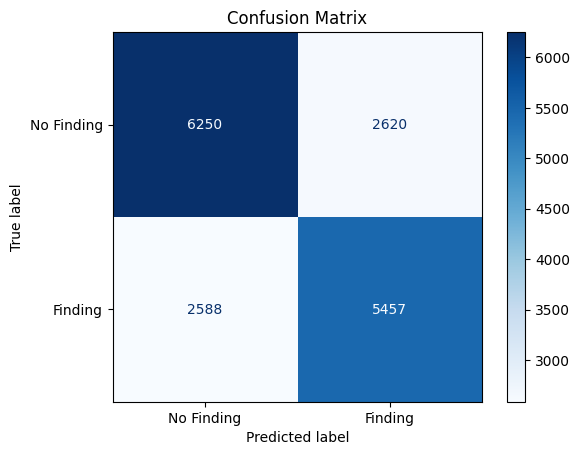

In [48]:
cm = confusion_matrix(all_test_labels,all_test_predictions)
display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No Finding','Finding'])
display.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()